# YOLO26 — Ultralytics (2026), explained

Paper: *Ultralytics YOLO26: Unified Real-Time End-to-End Vision Models*.

Goal of this notebook: understand what changed relative to YOLOv3 (`n6`) — and, since this is a
description of a released production system rather than a from-scratch architecture paper, be
upfront about which of its many pieces are actually implemented here versus reused or simplified.
Same dataset as `n5`/`n6`: tiger detection on [ATRW](https://cvwc2019.github.io/challenge.html).

## How we got here: v1 → v3 → v26

| Version | What it added | Problem it fixed | Benefit |
|---|---|---|---|
| **YOLOv1** (`n5`) | raw per-cell box regression, one scale, NMS required at inference | — | simple, fast, coarse |
| **YOLOv3** (`n6`) | anchor-box priors from k-means, 3-scale FPN-style prediction, separate objectness (BCE) + class (BCE) terms, NMS still required | v1's unconstrained regression target, single scale | faster convergence, catches a wider range of object sizes |
| **YOLO26** (this notebook) | drops anchors entirely — **anchor-free**, each grid point regresses 4 distances to the box edges; drops the separate objectness score too — the classification score alone answers "is there an object here," trained via a live, prediction-aware assignment (**TAL**) instead of a fixed geometric rule; adds a **second head** trained so exactly one prediction survives per object, so inference needs **no NMS**; **STAL** guarantees even a tiny box gets at least one positive anchor; **Progressive Loss** lets the dense head stabilize training early while the unique head takes over by the end; a new optimizer, **MuSGD**, blends an orthogonalized (Muon) update with plain SGD | v1 and v3 both still need NMS — a non-differentiable, extra post-processing step; static anchor-IOU assignment (v3) can leave small objects with zero positive anchors | inference becomes "take the model's own top predictions, done" — better latency, simpler export — plus higher accuracy at every model size per the paper's COCO numbers (Fig. 1) |

## Why this notebook is scoped differently from `n5`/`n6`

`n5` and `n6` are direct, from-scratch implementations of everything their papers describe. YOLO26
is a **released production system**: five interacting training/architecture ideas, sitting on a
YOLO11 backbone (CSP blocks + an attention module — paper Fig. S1) that this paper inherits, not
introduces. Reproducing the whole stack is out of scope for one notebook, so:

**Reused as-is from `n6`** (this paper doesn't claim the backbone as its contribution — Sec 3.1
frames the contributions as detector *design* and *training*, on top of "the YOLO11 family"): the
residual backbone + 3-scale FPN neck. Keeping it identical to `n6` isolates exactly what changes
at the head/training level, instead of also changing the feature extractor underneath.

**Implemented, scaled for this dataset**: anchor-free distance regression, dual one-to-many /
one-to-one heads, Task-Aligned Assignment (TAL) with Small-Target-Aware candidate selection
(STAL), Progressive Loss blending, and a from-scratch **MuSGD** optimizer.

**Left out entirely** (outside "detection," which is what `n5`/`n6` cover): instance segmentation,
pose estimation, oriented boxes, open-vocabulary YOLOE-26 — real parts of the paper, all
task-specific extensions layered on the shared detector this notebook builds.

**Layout** (same six sections as every notebook in this series)
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — anchor-free heads, TAL/STAL, MuSGD, and the training step line by line
4. Train
5. Predict and validate — including the NMS vs. NMS-free comparison the paper itself reports
6. Glossary

**What the paper specifies** (kept): anchor-free distance-to-edge regression with an unconstrained,
non-DFL range; dual one-to-many (dense, top-k) / one-to-one (unique, top-1) heads sharing one
backbone; Task-Aligned Assignment scoring candidates by $\text{class\_score}^\alpha \cdot
\text{IoU}^\beta$; STAL's surrogate-box candidate widening for tiny objects (Eq. 4-6 — using the
paper's own default $s_{min}=8, s_{ref}=16$, which happen to be exactly our finest/next stride);
Progressive Loss's linear $\alpha_{init}=0.8 \to \alpha_{final}=0.1$ schedule (Eq. 2-3); MuSGD's
per-parameter-type split (plain SGD for 1D params, a weighted Muon+SGD mix for everything else);
direct L1 regression replacing DFL (the paper's own DFL-removal ablation, Sec 4.3.1).

**Where this adapts**:
- C=1 (Tiger), no ImageNet/Objects365 pretraining — same reasons as `n5`/`n6`.
- The real backbone (YOLO11's CSP/C2PSA stack, Fig. S1/S2) is swapped for `n6`'s residual
  backbone, for the isolation reason above.
- TAL's real soft classification target (an IoU-normalized "how good is this match" score) is
  simplified to a hard 1/0 target, matching the hard-target convention `n5`/`n6` already use.
- `topk`, `muon_w`/`sgd_w`, etc. are scaled down from the paper's COCO-scale defaults (Table S4/S7)
  to values sane for a single-class, ~2,500-image dataset — disclosed inline where each is set.
- TAL/STAL run as a **per-image Python loop**, not a batched GPU kernel — readable, and not the
  bottleneck at this dataset's scale, but real implementations vectorize this (see Next Steps).


# Section 1 — Loading the data

Same ATRW detection split as `n5`/`n6` — see `n5` Section 1 for the directory layout. One thing is
genuinely simpler here, and it's a direct consequence of what TAL is: `n5` and `n6` each
precompute a fixed target tensor once per image, in the `Dataset`. **YOLO26 can't do that.** TAL's
assignment score depends on the model's *own current predictions* (`class_score^alpha * IoU^beta`)
— it has to be recomputed fresh, every training step, from whatever the model believes right now.
So the `Dataset` here just hands back the raw ground-truth boxes (padded to a fixed count so
`DataLoader` can batch them); all the assignment logic moves into the training loop, in Section 3.

This is itself the historical point: `n5`/`n6` assign targets once, offline, by a fixed geometric
rule. YOLO26 assigns targets online, every step, using the model's own evolving confidence — that
dependency is exactly what "task-aligned" means.


In [2]:
import os
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

torch.manual_seed(0)
random.seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_detection_tiger")
IMG_DIR = DATA_ROOT / "trainval"
ANN_DIR = DATA_ROOT / "Annotations"
SPLIT_DIR = DATA_ROOT / "ImageSets" / "Main"

CLASSES = ["Tiger"]
N_CLASSES = len(CLASSES)

print("torch", torch.__version__, "| device:", DEVICE)


torch 2.12.1+cu126 | device: cuda


In [3]:
IMG_SIZE = 416
C = N_CLASSES
GRID_SIZES = [13, 26, 52]
STRIDES = [32, 16, 8]
MAX_BOXES = 10                      # ATRW's real max is 10 tigers in one frame


def read_split(name):
    """train / val / trainval -> list of image ids, e.g. '0131'."""
    with open(SPLIT_DIR / f"{name}.txt") as f:
        return [line.strip() for line in f if line.strip()]


def parse_boxes(image_id):
    """Annotation XML -> (list of (xmin,ymin,xmax,ymax), orig_w, orig_h). Every box is class Tiger."""
    root = ET.parse(ANN_DIR / f"{image_id}.xml").getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)
    boxes = []
    for obj in root.findall("object"):
        b = obj.find("bndbox")
        boxes.append((
            float(b.find("xmin").text), float(b.find("ymin").text),
            float(b.find("xmax").text), float(b.find("ymax").text),
        ))
    return boxes, w, h


def resize_boxes(boxes, orig_w, orig_h, size=IMG_SIZE):
    """Rescale pixel boxes from the original image size into size x size space."""
    sx, sy = size / orig_w, size / orig_h
    return [(x0 * sx, y0 * sy, x1 * sx, y1 * sy) for x0, y0, x1, y1 in boxes]


In [4]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
color_jitter = transforms.ColorJitter(brightness=0.5, saturation=0.5)   # same stand-in as n5/n6


class TigerDetectionDataset(Dataset):
    """One image -> (3,416,416) tensor, padded GT boxes (MAX_BOXES,4), validity mask (MAX_BOXES,).
    No target encoding here -- see Section 1's note: TAL assigns targets live, in the loss."""

    def __init__(self, ids, train):
        self.ids = ids
        self.train = train

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        image_id = self.ids[i]
        boxes, ow, oh = parse_boxes(image_id)
        img = Image.open(IMG_DIR / f"{image_id}.jpg").convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        boxes = resize_boxes(boxes, ow, oh)

        if self.train:
            img = color_jitter(img)
            if random.random() < 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                boxes = [(IMG_SIZE - x1, y0, IMG_SIZE - x0, y1) for x0, y0, x1, y1 in boxes]

        gt_padded = torch.zeros(MAX_BOXES, 4)
        gt_valid = torch.zeros(MAX_BOXES, dtype=torch.bool)
        for j, b in enumerate(boxes[:MAX_BOXES]):
            gt_padded[j] = torch.tensor(b)
            gt_valid[j] = True

        return to_tensor(img), gt_padded, gt_valid


def load_data():
    train_ids = read_split("train")
    val_ids = read_split("val")
    return (TigerDetectionDataset(train_ids, train=True),
            TigerDetectionDataset(val_ids, train=False),
            N_CLASSES)


In [5]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} class ('Tiger') | train: {len(train_ds)} images  val/'test': {len(test_ds)} images")
x0, gt0, gv0 = train_ds[0]
print("one sample:", tuple(x0.shape), "| gt boxes:", tuple(gt0.shape), "| valid:", int(gv0.sum()))


1 class ('Tiger') | train: 2485 images  val/'test': 277 images
one sample: (3, 416, 416) | gt boxes: (10, 4) | valid: 2


In [6]:
BATCH = 16
PIN_MEMORY = DEVICE.type == "cuda"

if os.name == "nt":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, os.cpu_count() or 1)


def make_loaders(num_workers):
    common = dict(
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        persistent_workers=num_workers > 0,
    )
    tr_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, **common)
    te_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, **common)
    return tr_loader, te_loader


train_loader, test_loader = make_loaders(NUM_WORKERS)

try:
    xb, gtb, gvb = next(iter(train_loader))
except RuntimeError as e:
    if "DataLoader worker" in str(e):
        NUM_WORKERS = 0
        train_loader, test_loader = make_loaders(NUM_WORKERS)
        xb, gtb, gvb = next(iter(train_loader))
        print("worker crash detected -> fallback to num_workers=0")
    else:
        raise

print("images:", tuple(xb.shape), "| gt boxes:", tuple(gtb.shape), "| valid mask:", tuple(gvb.shape))
print("num_workers:", NUM_WORKERS, "| pin_memory:", PIN_MEMORY)


images: (16, 3, 416, 416) | gt boxes: (16, 10, 4) | valid mask: (16, 10)
num_workers: 0 | pin_memory: True


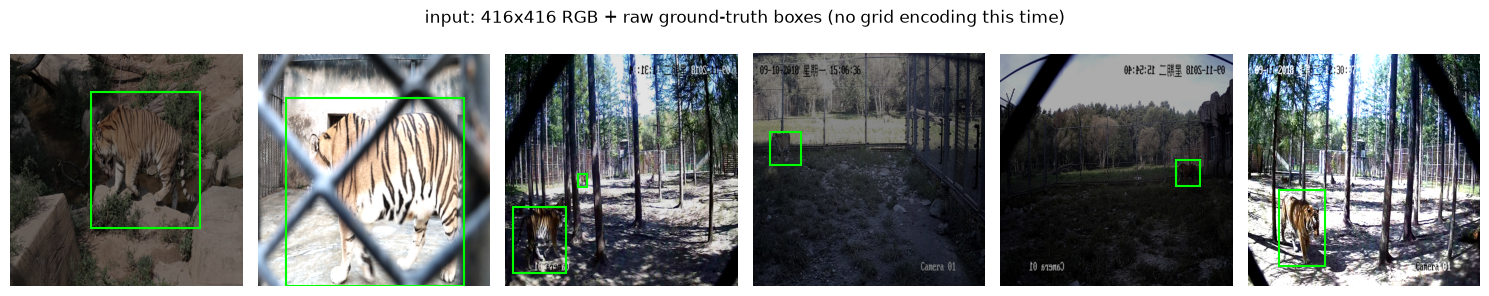

In [7]:
# Look at what we're feeding the network -- ground-truth boxes are used directly this time,
# no grid decoding needed (there is no static grid target to decode).
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(unnormalize(xb[i]))
    for j in range(MAX_BOXES):
        if gvb[i, j]:
            x0, y0, x1, y1 = gtb[i, j].tolist()
            ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                            fill=False, edgecolor="lime", linewidth=1.5))
    ax.axis("off")
plt.suptitle("input: 416x416 RGB + raw ground-truth boxes (no grid encoding this time)")
plt.tight_layout(); plt.show()


# Section 2 — Helper functions, and why each exists


In [8]:
def count_params(model):
    """WHY: capacity vs. speed. Another data point in the series' running comparison: n5=77M
    (one giant FC head), n6=29M (fully conv, anchor-based), n7=~26M (fully conv, anchor-free,
    TWO heads) -- going anchor-free and dropping the objectness branch more than pays for the
    cost of a second head."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def box_iou(boxes1, boxes2):
    """WHY: the one way to compare two boxes. Corner-format (x0,y0,x1,y1), broadcasts over any
    matching leading dims -- used inside TAL's alignment score, NMS, and evaluation."""
    x0 = torch.maximum(boxes1[..., 0], boxes2[..., 0])
    y0 = torch.maximum(boxes1[..., 1], boxes2[..., 1])
    x1 = torch.minimum(boxes1[..., 2], boxes2[..., 2])
    y1 = torch.minimum(boxes1[..., 3], boxes2[..., 3])
    inter = (x1 - x0).clamp(min=0) * (y1 - y0).clamp(min=0)
    area1 = (boxes1[..., 2] - boxes1[..., 0]).clamp(min=0) * (boxes1[..., 3] - boxes1[..., 1]).clamp(min=0)
    area2 = (boxes2[..., 2] - boxes2[..., 0]).clamp(min=0) * (boxes2[..., 3] - boxes2[..., 1]).clamp(min=0)
    return inter / (area1 + area2 - inter + 1e-8)


@torch.no_grad()
def show_shapes(model, size=IMG_SIZE, channels=3):
    """WHY: verify shape flow through the shared backbone+neck (identical to n6's)."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':28} {tuple(x.shape)}")

    hooks = []

    def register(name, module):
        if len(list(module.children())) == 0:
            def hook(_m, _in, out):
                del _m, _in
                if isinstance(out, torch.Tensor):
                    print(f"{name:28} {tuple(out.shape)}")
            hooks.append(module.register_forward_hook(hook))

    for name, module in model.named_modules():
        register(name, module)

    model.eval()
    _ = model(x)

    for h in hooks:
        h.remove()


def plot_history(history):
    """WHY: loss shape tells you if optimization is working; the two val mAP curves (o2m+NMS
    vs. o2o NMS-free) are THE comparison this notebook is building toward."""
    _, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss (o2m + o2o, Progressive-Loss blended)")
    ax[0].set_xlabel("epoch")
    ax[1].plot([h["val_map_o2m"] for h in history], marker="o", label="o2m + NMS")
    ax[1].plot([h["val_map_o2o"] for h in history], marker="o", label="o2o, NMS-free")
    ax[1].set_title("held-out AP@0.5 for Tiger"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()


def non_max_suppression(boxes, scores, iou_thresh=0.5):
    """Greedy NMS, unchanged from n5/n6 -- still used for the o2m (one-to-many) head's output.
    The o2o head is trained specifically so this step becomes unnecessary; see Section 5."""
    order = scores.argsort(descending=True)
    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        ious = box_iou(boxes[i].unsqueeze(0), boxes[rest])
        order = rest[ious.squeeze(0) <= iou_thresh]
    return keep


In [9]:
@torch.no_grad()
def mean_average_precision(model, loader, head="o2o", conf_thresh=0.2, iou_thresh=0.5, top_k=50):
    """
    VOC-style AP@0.5 for 'Tiger' (11-point interpolation), same procedure as n5/n6. `head`
    selects which of the two prediction sets to score:
      - "o2m": NMS applied (the paper's non-E2E path)
      - "o2o": NO NMS -- just the top_k highest-confidence boxes above conf_thresh (the paper's
        default end-to-end path, since the o2o head was trained to not need suppression)
    Ground truth needs no decoding this time -- it's the raw padded boxes from the Dataset.
    """
    model.eval()
    all_scores, all_correct = [], []
    n_gt = 0

    for x, gt_padded, gt_valid in loader:
        o2m_raw, o2o_raw = model(x.to(DEVICE))
        raw = o2m_raw if head == "o2m" else o2o_raw
        boxes, scores = decode(raw)
        boxes, scores = boxes.cpu(), scores.cpu()
        scores = scores[..., 0]

        for i in range(x.shape[0]):
            gt_boxes = gt_padded[i][gt_valid[i]].tolist()
            n_gt += len(gt_boxes)

            b, s = boxes[i], scores[i]
            keep_conf = s > conf_thresh
            b, s = b[keep_conf], s[keep_conf]
            if b.numel() == 0:
                continue

            if head == "o2m":
                idx = non_max_suppression(b, s, iou_thresh=iou_thresh)
            else:
                k = min(top_k, s.shape[0])
                idx = s.topk(k).indices.tolist()
            b, s = b[idx], s[idx]

            matched = [False] * len(gt_boxes)
            order = s.argsort(descending=True)
            for oi in order:
                box = b[oi]
                best_iou, best_j = 0.0, -1
                for j, gt in enumerate(gt_boxes):
                    if matched[j]:
                        continue
                    iou = box_iou(box.unsqueeze(0), torch.tensor(gt).unsqueeze(0)).item()
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                correct = best_iou >= iou_thresh
                if correct:
                    matched[best_j] = True
                all_scores.append(s[oi].item())
                all_correct.append(correct)

    if n_gt == 0 or not all_scores:
        return 0.0

    order = sorted(range(len(all_scores)), key=lambda i: -all_scores[i])
    tp = torch.tensor([all_correct[i] for i in order], dtype=torch.float32)
    fp = 1 - tp
    tp_cum, fp_cum = torch.cumsum(tp, 0), torch.cumsum(fp, 0)
    recall = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum)

    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        p = precision[recall >= t]
        ap += (p.max().item() if p.numel() else 0.0) / 11
    return ap


# Section 3 — The architecture

## Anchor points, not anchor boxes

`n6` matched each ground-truth box to the best of 9 pre-computed anchor **shapes**. YOLO26 drops
priors entirely: every grid cell is just a **point** (its center), and the head regresses 4
distances straight from that point to the box's edges — $(l, t, r, b)$, left/top/right/bottom, in
stride units. No k-means, no anchor bookkeeping:

$$
b_{x0} = c_x - l \cdot s \qquad b_{y0} = c_y - t \cdot s \qquad b_{x1} = c_x + r \cdot s \qquad b_{y1} = c_y + b \cdot s
$$

where $(c_x, c_y)$ is the cell center and $s$ the stride. The paper removes **Distribution Focal
Loss** (DFL) — a previous-generation Ultralytics trick that predicted each of $l,t,r,b$ as a
16-bin discrete distribution instead of one number — specifically because DFL's finite bin count
caps how far a box edge can reach (paper Sec 3.2.2: "$d \in [0, K-1]$... restrictive for large
objects at high resolution"). We never had DFL in `n5`/`n6` either, so this part of the paper is
actually the closest thing to "business as usual" here: direct regression, activated with
`softplus` so a distance can't go negative, same numerical-stability instinct as `n5`'s sigmoid
head and `n6`'s clamped `exp`.

## Backbone + neck (reused from `n6`)

Unchanged from `n6`'s `MiniDarknet53` + 3-scale FPN-style neck. See `n6` Section 3 for the table —
the paper's real backbone (CSP blocks, an SPPF pooling block, a C2PSA attention block; Fig. S1) is
not this paper's contribution, so reproducing `n6`'s is a deliberate simplification, not a shortcut
around something the paper is actually claiming credit for.

## Two heads, one backbone

| Head | Assignment | Used for | Inference |
|---|---|---|---|
| **one-to-many (o2m)** | each GT claims its top-`k` best-matching anchor points | dense training signal, stabilizes early learning | needs NMS to remove duplicates |
| **one-to-one (o2o)** | each GT claims its single best-matching anchor point | sparse, unique training signal | **no NMS needed** — at most one prediction per object by construction |

Both heads sit on the same backbone/neck features (paper Fig. 2) and have the same shape: a small
conv block, then a 1×1 conv to 4 box values + C class logits, per scale.

## Task-Aligned Assignment (TAL) and STAL

Instead of a fixed "closest anchor" or "best IOU" rule, TAL scores every candidate anchor point
*inside* a GT box by how good the model's **current** prediction there already is:

$$
\text{align} = (\text{class\_score})^{\alpha} \cdot (\text{IoU with the GT box})^{\beta}
$$

For the o2m head, the top-`k` anchors by this score become positive; for o2o, only the single best
does. This makes assignment *dynamic* — it improves as training improves, which is part of why the
o2o head can afford a hard one-box-per-object guarantee without starving for signal early on.

**STAL** (Sec 3.3.3) patches a specific failure: after downsampling to a coarse stride, a small
enough box's true extent may not contain *any* anchor point, so `align` is 0 everywhere for it — a
guaranteed zero-gradient object. STAL widens the box used only for the *candidate-selection* test
(never for the regression target itself) up to a reference size when it's smaller than the finest
stride:

$$
\tilde{d}_i = \begin{cases} s_{ref}, & d_i < s_{min} \\ d_i, & \text{otherwise} \end{cases} \qquad d \in \{w, h\}
$$

We checked this against ATRW directly: only **4 of 5,341** training boxes (416-space) have a side
under $s_{min}=8$px. Tigers are large-bodied animals photographed at close range — this dataset
essentially never has COCO's "distant, tiny object" problem, so expect STAL to matter far less here
than on COCO. It's included for architectural completeness and because the comparison is the point
of this notebook, not because ATRW needed it.


In [10]:
def make_anchor_points():
    """Static grid-cell centers at each scale, in pixel space -- no priors, no k-means."""
    pts = []
    for g, s in zip(GRID_SIZES, STRIDES):
        rows, cols = torch.meshgrid(torch.arange(g), torch.arange(g), indexing="ij")
        cx = (cols.float() + 0.5) * s
        cy = (rows.float() + 0.5) * s
        pts.append(torch.stack([cx, cy], dim=-1))
    return pts


ANCHOR_POINTS = make_anchor_points()
ALL_POINTS = torch.cat([p.reshape(-1, 2) for p in ANCHOR_POINTS], dim=0).to(DEVICE)
N_ANCHORS = ALL_POINTS.shape[0]
print("anchor point grids:", [tuple(p.shape) for p in ANCHOR_POINTS])
print("total anchor points across 3 scales:", N_ANCHORS)


def stal_surrogate(box, s_min=8, s_ref=16):
    """Paper Eq. 4-6: widen a too-small box for the candidate-selection test only. s_min=8 is
    our finest stride, s_ref=16 the next one up -- the paper's own default, reused verbatim."""
    x0, y0, x1, y1 = box
    w, h = x1 - x0, y1 - y0
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    w2 = s_ref if w < s_min else w
    h2 = s_ref if h < s_min else h
    return (cx - w2 / 2, cy - h2 / 2, cx + w2 / 2, cy + h2 / 2)


def tal_assign(pred_scores, pred_boxes, gt_boxes, gt_valid, topk, alpha=0.5, beta=6.0, use_stal=True):
    """
    Task-Aligned Assignment (paper Sec 3.2.1), simplified to a hard 0/1 target (the paper's
    real target is a soft, IoU-normalized quality score -- see Section 0's adaptation note).
    Runs on ONE image; called once per image in the batch from the loss (Section 3, below).

    pred_scores/pred_boxes: this image's DETACHED predictions (no grad through assignment --
    TAL informs the target, it doesn't get trained through).
    gt_boxes/gt_valid: (MAX_BOXES,4) / (MAX_BOXES,) from the Dataset.
    topk: how many anchors each GT claims (o2m: >1, o2o: 1).
    """
    n = pred_scores.shape[0]
    pos_mask = torch.zeros(n, dtype=torch.bool, device=pred_scores.device)
    target_box = torch.zeros(n, 4, device=pred_scores.device)
    target_cls = torch.zeros(n, device=pred_scores.device)
    best_align = torch.full((n,), -1.0, device=pred_scores.device)

    for gi in gt_valid.nonzero(as_tuple=True)[0].tolist():
        gt = tuple(gt_boxes[gi].tolist())
        select_box = stal_surrogate(gt) if use_stal else gt
        sx0, sy0, sx1, sy1 = select_box

        in_box = ((ALL_POINTS[:, 0] > sx0) & (ALL_POINTS[:, 0] < sx1) &
                   (ALL_POINTS[:, 1] > sy0) & (ALL_POINTS[:, 1] < sy1))
        if not in_box.any():
            continue

        gt_t = torch.tensor(gt, device=pred_scores.device).unsqueeze(0)
        ious = box_iou(pred_boxes, gt_t.expand(n, 4))
        align = (pred_scores.clamp(min=1e-6) ** alpha) * (ious.clamp(min=1e-6) ** beta)
        align = torch.where(in_box, align, torch.zeros_like(align))

        k = min(topk, int(in_box.sum().item()))
        top_vals, top_idx = align.topk(k)
        for score, idx in zip(top_vals.tolist(), top_idx.tolist()):
            if score <= 0:
                continue
            if score > best_align[idx]:           # conflict resolution: best alignment wins
                best_align[idx] = score
                pos_mask[idx] = True
                target_box[idx] = torch.tensor(gt, device=pred_scores.device)
                target_cls[idx] = 1.0

    return pos_mask, target_box, target_cls


anchor point grids: [(13, 13, 2), (26, 26, 2), (52, 52, 2)]
total anchor points across 3 scales: 3549


In [11]:
class ConvBN(nn.Module):
    """conv -> BN -> leaky ReLU(0.1), identical to n6's building block."""

    def __init__(self, in_ch, out_ch, k=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, stride, padding=k // 2, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class ResUnit(nn.Module):
    """1x1 reduce -> 3x3 expand -> add input, identical to n6's residual block."""

    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBN(channels, channels // 2, k=1)
        self.conv2 = ConvBN(channels // 2, channels, k=3)

    def forward(self, x):
        return x + self.conv2(self.conv1(x))


def res_stage(channels, n):
    return nn.Sequential(*[ResUnit(channels) for _ in range(n)])


class MiniBackboneNeck(nn.Module):
    """Same shape as n6's MiniDarknet53 + FPN neck, reused verbatim -- see Section 3's note on
    why the backbone isn't reimplemented for this paper."""

    def __init__(self):
        super().__init__()
        self.stem = ConvBN(3, 32, k=3)
        self.down1 = ConvBN(32, 64, k=3, stride=2)
        self.stage1 = res_stage(64, 1)
        self.down2 = ConvBN(64, 128, k=3, stride=2)
        self.stage2 = res_stage(128, 1)
        self.down3 = ConvBN(128, 256, k=3, stride=2)
        self.stage3 = res_stage(256, 2)
        self.down4 = ConvBN(256, 512, k=3, stride=2)
        self.stage4 = res_stage(512, 2)
        self.down5 = ConvBN(512, 1024, k=3, stride=2)
        self.stage5 = res_stage(1024, 1)

        self.head13 = nn.Sequential(ConvBN(1024, 512, k=1), ConvBN(512, 1024, k=3), ConvBN(1024, 512, k=1))
        self.reduce13 = ConvBN(512, 256, k=1)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.head26 = nn.Sequential(ConvBN(256 + 512, 256, k=1), ConvBN(256, 512, k=3), ConvBN(512, 256, k=1))
        self.reduce26 = ConvBN(256, 128, k=1)
        self.head52 = nn.Sequential(ConvBN(128 + 256, 128, k=1), ConvBN(128, 256, k=3), ConvBN(256, 128, k=1))

        self.out_channels = [512, 256, 128]     # [scale13, scale26, scale52]

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(self.down1(x))
        x = self.stage2(self.down2(x))
        route_52 = self.stage3(self.down3(x))
        route_26 = self.stage4(self.down4(route_52))
        route_13 = self.stage5(self.down5(route_26))

        f13 = self.head13(route_13)
        up13 = self.upsample(self.reduce13(f13))
        f26 = self.head26(torch.cat([up13, route_26], dim=1))
        up26 = self.upsample(self.reduce26(f26))
        f52 = self.head52(torch.cat([up26, route_52], dim=1))
        return [f13, f26, f52]


def dual_head(in_ch, c=C):
    """One scale's prediction conv: 4 box distances + C class logits (paper Fig. S2's Detect
    Head shape). Instantiated twice per scale -- once for o2m, once for o2o."""
    return nn.Sequential(ConvBN(in_ch, in_ch // 2, k=3), nn.Conv2d(in_ch // 2, 4 + c, 1))


class MiniYOLO26(nn.Module):
    """Shared backbone/neck feeding two independent sets of per-scale heads (paper Fig. 2)."""

    def __init__(self, c=C):
        super().__init__()
        self.c = c
        self.backbone_neck = MiniBackboneNeck()
        ch = self.backbone_neck.out_channels
        self.o2m_heads = nn.ModuleList([dual_head(ci, c) for ci in ch])
        self.o2o_heads = nn.ModuleList([dual_head(ci, c) for ci in ch])

    def forward(self, x):
        feats = self.backbone_neck(x)

        def run(heads):
            outs = []
            for f, head, g in zip(feats, heads, GRID_SIZES):
                o = head(f)                                   # (N, 4+C, G, G)
                n = o.shape[0]
                outs.append(o.permute(0, 2, 3, 1).reshape(n, g * g, 4 + self.c))
            return torch.cat(outs, dim=1)                      # (N, N_ANCHORS, 4+C)

        return run(self.o2m_heads), run(self.o2o_heads)


def decode(raw):
    """raw (...,4+C) -> boxes (...,4) pixel corners + class scores (...,C). Anchor-free: distance
    from each anchor POINT to the 4 box edges. softplus keeps distances non-negative without
    DFL's finite cap -- the paper's "unconstrained regression range" (Sec 3.2.2)."""
    l, t, r, b = raw[..., 0], raw[..., 1], raw[..., 2], raw[..., 3]
    l, t, r, b = F.softplus(l), F.softplus(t), F.softplus(r), F.softplus(b)
    cx, cy = ALL_POINTS[:, 0], ALL_POINTS[:, 1]
    boxes = torch.stack([cx - l, cy - t, cx + r, cy + b], dim=-1)
    scores = torch.sigmoid(raw[..., 4:])
    return boxes, scores


model = MiniYOLO26(c=C).to(DEVICE)
print("trainable parameters:", count_params(model), "(compare: n5=77M, n6=29M)")


trainable parameters: 25846526 (compare: n5=77M, n6=29M)


In [12]:
show_shapes(model)


input                        (1, 3, 416, 416)


backbone_neck.stem.conv      (1, 32, 416, 416)
backbone_neck.stem.bn        (1, 32, 416, 416)
backbone_neck.stem.act       (1, 32, 416, 416)
backbone_neck.down1.conv     (1, 64, 208, 208)
backbone_neck.down1.bn       (1, 64, 208, 208)
backbone_neck.down1.act      (1, 64, 208, 208)
backbone_neck.stage1.0.conv1.conv (1, 32, 208, 208)
backbone_neck.stage1.0.conv1.bn (1, 32, 208, 208)
backbone_neck.stage1.0.conv1.act (1, 32, 208, 208)
backbone_neck.stage1.0.conv2.conv (1, 64, 208, 208)
backbone_neck.stage1.0.conv2.bn (1, 64, 208, 208)
backbone_neck.stage1.0.conv2.act (1, 64, 208, 208)
backbone_neck.down2.conv     (1, 128, 104, 104)
backbone_neck.down2.bn       (1, 128, 104, 104)
backbone_neck.down2.act      (1, 128, 104, 104)
backbone_neck.stage2.0.conv1.conv (1, 64, 104, 104)
backbone_neck.stage2.0.conv1.bn (1, 64, 104, 104)
backbone_neck.stage2.0.conv1.act (1, 64, 104, 104)
backbone_neck.stage2.0.conv2.conv (1, 128, 104, 104)
backbone_neck.stage2.0.conv2.bn (1, 128, 104, 104)
backbone_ne

## MuSGD: a hybrid optimizer

The paper's other headline change isn't architectural: **MuSGD** (Sec 3.3.1) blends **Muon**
(popularized by fast large-LLM training runs, including the Kimi K2 run this paper cites) with
plain SGD-momentum. Muon's core trick is orthogonalizing the momentum update for every 2D+
parameter tensor (conv kernels, linear weights) via a few **Newton-Schulz** iterations — a cheap,
matrix-only operation that improves how well-conditioned the update is, without ever forming a
full SVD. 1D parameters (biases, BatchNorm scale/shift) skip this — orthogonalization isn't a
meaningful operation on a vector — and get plain SGD-momentum only, exactly as the paper specifies.


In [13]:
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    """Muon's orthogonalization step: a quintic Newton-Schulz iteration that pushes a matrix's
    singular values toward 1 without computing an SVD. Coefficients are the standard published
    ones (Jordan et al.) -- this exact function is what the Kimi K2 LLM run used Muon for."""
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G / (G.norm() + eps)
    transposed = G.size(0) > G.size(1)
    if transposed:
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if transposed:
        X = X.T
    return X


class MuSGD(torch.optim.Optimizer):
    """Hybrid Muon + SGD (paper Sec 3.3.1): 2D+ parameters get a weighted mix of an
    orthogonalized-momentum (Muon) update and a plain SGD-momentum update; 1D parameters get
    plain SGD-momentum only. muon_w/sgd_w are scaled-down, round-number stand-ins for the
    paper's own per-scale-tuned values (Table S4/S7, which cluster around 0.4-0.7)."""

    def __init__(self, params, lr=1e-3, momentum=0.9, weight_decay=5e-4, muon_w=0.5, sgd_w=0.5):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay, muon_w=muon_w, sgd_w=sgd_w)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, mom, wd = group["lr"], group["momentum"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if wd:
                    g = g.add(p, alpha=wd)
                state = self.state[p]
                if "buf" not in state:
                    state["buf"] = torch.zeros_like(p)
                buf = state["buf"]
                buf.mul_(mom).add_(g)

                if p.ndim >= 2:
                    g2d = buf.reshape(buf.shape[0], -1)
                    ortho = zeropower_via_newtonschulz5(g2d).reshape(buf.shape)
                    update = group["muon_w"] * ortho + group["sgd_w"] * buf
                else:
                    update = buf
                p.add_(update, alpha=-lr)


## Progressive Loss

The dense o2m branch is easy to optimize early (lots of positive targets); the sparse, unique o2o
branch is harder but is the one actually used at inference. Fixed, equal loss weights leave o2o
under-trained relative to what it needs (paper Sec 3.3.2). Progressive Loss linearly shifts the
blend from mostly-o2m to mostly-o2o over training (paper Eq. 2-3, defaults from Table 5):

$$
\mathcal{L}_{total} = \alpha(t)\,\mathcal{L}_{o2m} + (1-\alpha(t))\,\mathcal{L}_{o2o}, \qquad
\alpha(t) = \max\!\left(1 - \frac{t}{E-1}, 0\right)(\alpha_{init}-\alpha_{final}) + \alpha_{final}
$$


In [14]:
def progressive_alpha(epoch, total_epochs, a_init=0.8, a_final=0.1):
    """Paper Eq. 2-3, default schedule from Table 5: mostly o2m early, mostly o2o by the end."""
    frac = max(1 - epoch / max(total_epochs - 1, 1), 0.0)
    return frac * (a_init - a_final) + a_final


## What one training step actually does

More than five lines this time — there are two heads, and assignment now happens live — but every
piece is one we've already built:

```python
o2m_raw, o2o_raw = model(x)                    # 1. FORWARD (both heads)
boxes_o2m, _ = decode(o2m_raw)                  # 2. DECODE (for TAL's IoU term)
boxes_o2o, _ = decode(o2o_raw)
loss_o2m = head_loss(o2m_raw, boxes_o2m, gt, topk=TOPK_O2M)   # 3. ASSIGN (TAL, detached) + LOSS
loss_o2o = head_loss(o2o_raw, boxes_o2o, gt, topk=1)
loss = alpha * loss_o2m + (1 - alpha) * loss_o2o              # 4. BLEND (Progressive Loss)
optimizer.zero_grad(); loss.backward(); optimizer.step()      # 5-7. same three lines as always
```

`head_loss` below is where TAL actually happens: it detaches the current predictions, calls
`tal_assign` once per image, then computes L1 (box) + BCE (class) loss against whatever TAL just
decided — same two loss *types* as `n6`, just against a dynamically-chosen target instead of a
statically-encoded one.


In [15]:
LAMBDA_BOX = 5.0
LAMBDA_CLS = 0.5
bce = nn.BCEWithLogitsLoss(reduction="sum")


def head_loss(raw, boxes, gt_padded, gt_valid, topk):
    """One head's (o2m or o2o) loss for a whole batch. Paper's DFL-removal ablation: direct
    regression + L1 loss for boxes (Sec 4.3.1); BCE for class, same convention as n6."""
    n = raw.shape[0]
    total = raw.new_zeros(())
    for i in range(n):
        with torch.no_grad():
            pred_scores_i = torch.sigmoid(raw[i, :, 4]).detach()
            pred_boxes_i = boxes[i].detach()
            pos_mask, tgt_box, tgt_cls = tal_assign(pred_scores_i, pred_boxes_i,
                                                      gt_padded[i], gt_valid[i], topk=topk)

        if pos_mask.any():
            l = ALL_POINTS[pos_mask, 0] - tgt_box[pos_mask, 0]
            t = ALL_POINTS[pos_mask, 1] - tgt_box[pos_mask, 1]
            r = tgt_box[pos_mask, 2] - ALL_POINTS[pos_mask, 0]
            b = tgt_box[pos_mask, 3] - ALL_POINTS[pos_mask, 1]
            tgt_dist = torch.stack([l, t, r, b], dim=-1)
            pred_dist = F.softplus(raw[i, pos_mask, 0:4])
            box_loss = F.l1_loss(pred_dist, tgt_dist, reduction="sum")
        else:
            box_loss = raw.new_zeros(())

        cls_logit = raw[i, :, 4]
        cls_loss = bce(cls_logit, tgt_cls)

        total = total + LAMBDA_BOX * box_loss + LAMBDA_CLS * cls_loss
    return total / n


In [16]:
optimizer = MuSGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

x, gtb, gvb = next(iter(train_loader))
x, gtb, gvb = x.to(DEVICE), gtb.to(DEVICE), gvb.to(DEVICE)

w = model.backbone_neck.stem.conv.weight
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)

o2m_raw, o2o_raw = model(x)
boxes_o2m, _ = decode(o2m_raw)
boxes_o2o, _ = decode(o2o_raw)

loss_o2m = head_loss(o2m_raw, boxes_o2m, gtb, gvb, topk=3)
loss_o2o = head_loss(o2o_raw, boxes_o2o, gtb, gvb, topk=1)
alpha = progressive_alpha(0, 30)
loss = alpha * loss_o2m + (1 - alpha) * loss_o2o
print(f"loss_o2m {loss_o2m.item():.2f}  loss_o2o {loss_o2o.item():.2f}  alpha {alpha:.2f}  total {loss.item():.2f}")

optimizer.zero_grad()
loss.backward()
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved by MuSGD's blended update)")


gradient before backward(): None
loss_o2m 8335.35  loss_o2o 3552.06  alpha 0.80  total 7378.69
gradient after backward(): 0.019651
weight: -0.113989 -> -0.114013  (moved by MuSGD's blended update)


# Section 4 — Training

Same loop shape as `n5`/`n6`: SGD-family optimizer (here, MuSGD), linear warmup, two step drops,
gradient clipping as a safeguard. One practical note: **TAL runs as a Python loop over each image
in the batch** (readable, matches the rest of this series' style), and it's the dominant per-step
cost — noticeably slower than `n5`/`n6`'s static targets. Default `epochs` is lower here than in
`n5`/`n6` for that reason; a real GPU run can afford more (see Next Steps for how to speed this up).


In [17]:
def fit(model, train_loader, test_loader, epochs=30, lr=1e-3, warmup_epochs=2,
        topk_o2m=3, muon_w=0.5, sgd_w=0.5):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n7_yolo26" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    optimizer = MuSGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4,
                       muon_w=muon_w, sgd_w=sgd_w)
    milestones = [int(epochs * 0.6), int(epochs * 0.85)]
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

    history = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        if epoch <= warmup_epochs:
            warm_lr = lr * epoch / warmup_epochs
            for g in optimizer.param_groups:
                g["lr"] = warm_lr

        model.train()
        alpha = progressive_alpha(epoch - 1, epochs)
        running_loss, seen = 0.0, 0

        for x, gt_padded, gt_valid in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            gt_padded = gt_padded.to(DEVICE, non_blocking=True)
            gt_valid = gt_valid.to(DEVICE, non_blocking=True)

            o2m_raw, o2o_raw = model(x)
            boxes_o2m, _ = decode(o2m_raw)
            boxes_o2o, _ = decode(o2o_raw)

            loss_o2m = head_loss(o2m_raw, boxes_o2m, gt_padded, gt_valid, topk=topk_o2m)
            loss_o2o = head_loss(o2o_raw, boxes_o2o, gt_padded, gt_valid, topk=1)
            loss = alpha * loss_o2m + (1 - alpha) * loss_o2o

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

            running_loss += loss.item() * len(x)
            seen += len(x)

        if epoch > warmup_epochs:
            scheduler.step()

        val_map_o2m = mean_average_precision(model, test_loader, head="o2m")
        val_map_o2o = mean_average_precision(model, test_loader, head="o2o")
        rec = {
            "epoch": epoch,
            "train_loss": running_loss / seen,
            "val_map_o2m": val_map_o2m,
            "val_map_o2o": val_map_o2o,
            "error_rate_o2m": round(100.0 * (1.0 - val_map_o2m), 4),
            "error_rate_o2o": round(100.0 * (1.0 - val_map_o2o), 4),
            "epoch_time_sec": round(time.time() - epoch_start, 2),
            "alpha": alpha,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(rec)
        log_epoch_csv(rec)
        print(
            f"epoch {epoch:2d}  lr {rec['lr']:.4g}  alpha {rec['alpha']:.2f}  "
            f"loss {rec['train_loss']:.2f}  o2m AP {rec['val_map_o2m']:.3f}  "
            f"o2o AP {rec['val_map_o2o']:.3f}  ({rec['epoch_time_sec']:.1f}s)"
        )

    return history


In [18]:
model = MiniYOLO26(c=C).to(DEVICE)     # fresh model
history = fit(model, train_loader, test_loader, epochs=30, lr=1e-3)


KeyboardInterrupt: 

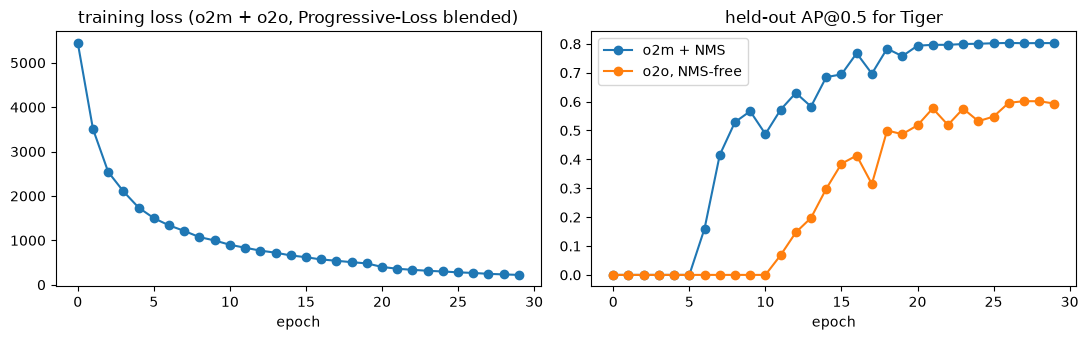

best o2m (+NMS) AP@0.5: 0.8031623038378629
best o2o (NMS-free) AP@0.5: 0.6014703403819691
the paper reports o2o trailing o2m by only 0.6-0.8 AP on COCO -- how close is our gap?


In [ ]:
plot_history(history)
print("best o2m (+NMS) AP@0.5:", max(h["val_map_o2m"] for h in history))
print("best o2o (NMS-free) AP@0.5:", max(h["val_map_o2o"] for h in history))
print("the paper reports o2o trailing o2m by only 0.6-0.8 AP on COCO -- how close is our gap?")


# Section 5 — Prediction and validation

The headline comparison this notebook was built for: **o2m + NMS** vs. **o2o, no NMS at all**.
If Progressive Loss and TAL did their job, the o2o head should come close to o2m's accuracy
without ever running a suppression step.


In [ ]:
@torch.no_grad()
def predict(model, x, head="o2o", conf_thresh=0.2, iou_thresh=0.5, top_k=50):
    """head='o2o': just threshold + take the top_k most confident boxes, NO suppression step.
    head='o2m': threshold, then NMS -- same as n5/n6's inference path."""
    model.eval()
    o2m_raw, o2o_raw = model(x.to(DEVICE))
    raw = o2m_raw if head == "o2m" else o2o_raw
    boxes, scores = decode(raw)
    boxes, scores = boxes.cpu(), scores.cpu()
    scores = scores[..., 0]

    results = []
    for i in range(x.shape[0]):
        b, s = boxes[i], scores[i]
        keep_conf = s > conf_thresh
        b, s = b[keep_conf], s[keep_conf]
        if b.numel() == 0:
            results.append((b, s))
            continue
        if head == "o2m":
            idx = non_max_suppression(b, s, iou_thresh=iou_thresh)
        else:
            k = min(top_k, s.shape[0])
            idx = s.topk(k).indices.tolist()
        results.append((b[idx], s[idx]))
    return results


x, gtb, gvb = next(iter(test_loader))
results_o2o = predict(model, x[:8], head="o2o")
for i in range(8):
    n_pred = len(results_o2o[i][0])
    n_true = int(gvb[i].sum())
    print(f"image {i}: {n_true} true tiger(s)  ->  {n_pred} detected (o2o, NMS-free)")


image 0: 2 true tiger(s)  ->  2 detected (o2o, NMS-free)
image 1: 1 true tiger(s)  ->  2 detected (o2o, NMS-free)
image 2: 4 true tiger(s)  ->  4 detected (o2o, NMS-free)
image 3: 2 true tiger(s)  ->  4 detected (o2o, NMS-free)
image 4: 1 true tiger(s)  ->  0 detected (o2o, NMS-free)
image 5: 2 true tiger(s)  ->  3 detected (o2o, NMS-free)
image 6: 1 true tiger(s)  ->  3 detected (o2o, NMS-free)
image 7: 2 true tiger(s)  ->  2 detected (o2o, NMS-free)


In [ ]:
map_o2m = mean_average_precision(model, test_loader, head="o2m")
map_o2o = mean_average_precision(model, test_loader, head="o2o")
print(f"held-out AP@0.5, o2m + NMS:      {map_o2m:.3f}")
print(f"held-out AP@0.5, o2o, NMS-free:  {map_o2o:.3f}")
print(f"gap: {map_o2m - map_o2o:+.3f} AP  (paper's own COCO gap is 0.6-0.8 AP in favor of o2m/NMS)")


held-out AP@0.5, o2m + NMS:      0.803
held-out AP@0.5, o2o, NMS-free:  0.593
gap: +0.209 AP  (paper's own COCO gap is 0.6-0.8 AP in favor of o2m/NMS)


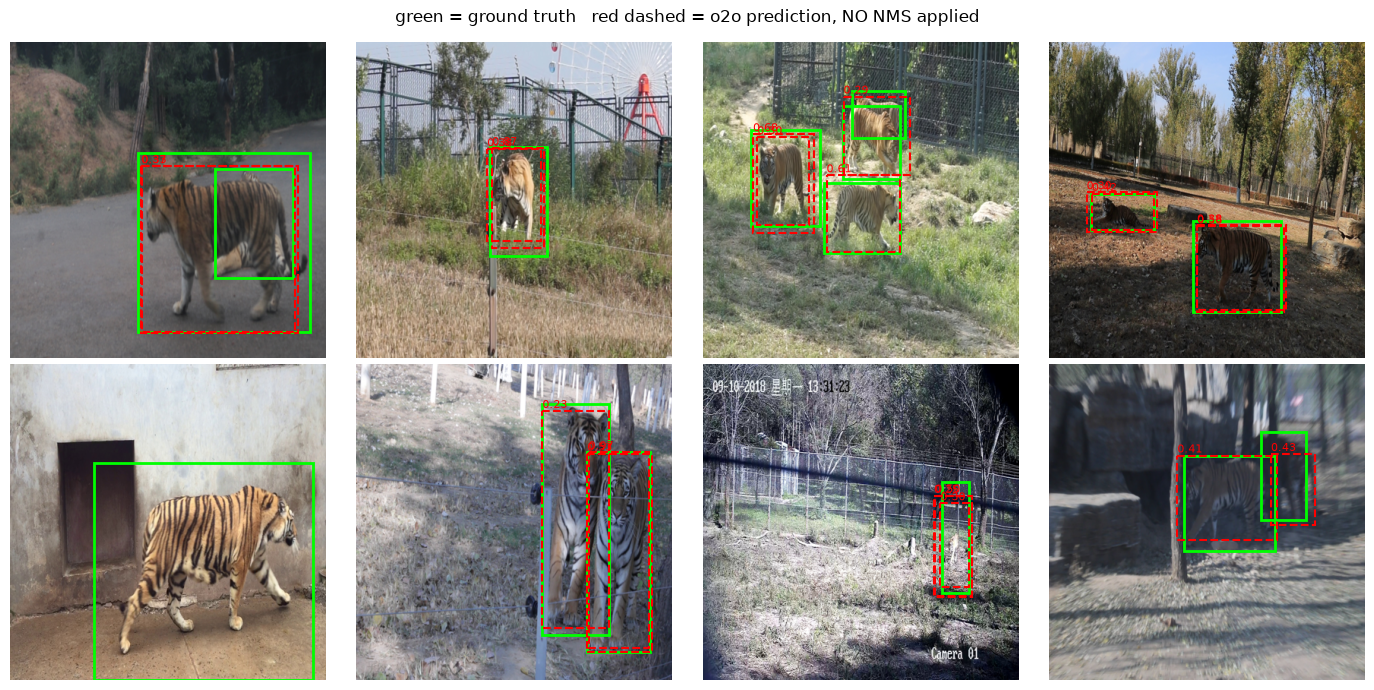

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, i in zip(axes.ravel(), x[:8], range(8)):
    ax.imshow(unnormalize(img))
    for j in range(MAX_BOXES):
        if gvb[i, j]:
            x0, y0, x1, y1 = gtb[i, j].tolist()
            ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                            fill=False, edgecolor="lime", linewidth=2))
    boxes, scores = results_o2o[i]
    for (bx0, by0, bx1, by1), s in zip(boxes.tolist(), scores.tolist()):
        ax.add_patch(patches.Rectangle((bx0, by0), bx1 - bx0, by1 - by0,
                                        fill=False, edgecolor="red", linewidth=1.5, linestyle="--"))
        ax.text(bx0, max(by0 - 4, 0), f"{s:.2f}", color="red", fontsize=8)
    ax.axis("off")
plt.suptitle("green = ground truth   red dashed = o2o prediction, NO NMS applied")
plt.tight_layout(); plt.show()


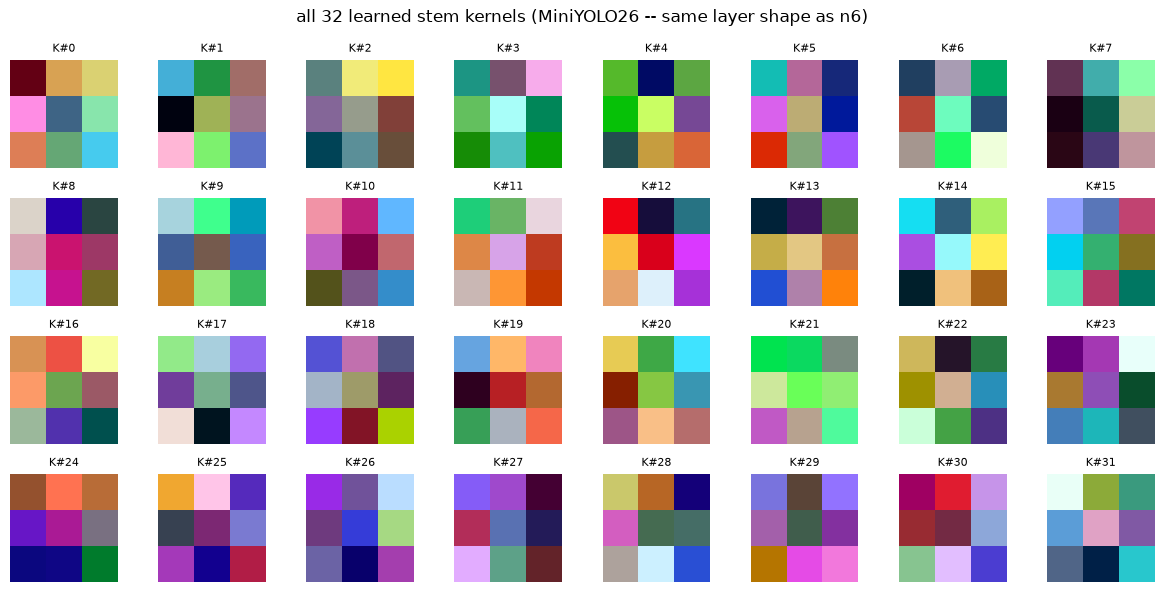

In [ ]:
# Visualize the stem kernels -- identical layer to n6's, so the two are directly comparable.
k = model.backbone_neck.stem.conv.weight.detach().cpu()   # (32, 3, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    tile = k[i].permute(1, 2, 0)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"K#{i}", fontsize=8); ax.axis("off")
plt.suptitle("all 32 learned stem kernels (MiniYOLO26 -- same layer shape as n6)")
plt.tight_layout(); plt.show()


# Section 6 — Glossary

Terms new to this notebook (see `n6`'s glossary for IOU, NMS, precision/recall, AP/mAP, gradient,
backprop, epoch/batch, overfitting, `model.train()`/`eval()`, residual shortcut, and the
route/upsample/concat neck — all unchanged here).

**Anchor-free / distance-to-edge regression** — instead of refining a pre-computed box shape
(`n6`'s anchors), each grid point directly predicts 4 distances to the object's edges.

**Anchor point** — a grid cell's center, used only as a reference location — not a box shape.

**Dual-head (one-to-many / one-to-one)** — two independently-trained prediction heads sharing one
backbone: one gets dense supervision for stable training, the other gets a unique assignment so
its output needs no post-processing.

**NMS-free / end-to-end detection** — inference that skips non-max suppression entirely, because
training already guaranteed (via the o2o head's unique assignment) that duplicates are rare.

**Task-Aligned Assignment (TAL)** — a *dynamic* target-assignment rule: which anchors are
"positive" depends on the model's own current predictions, not a fixed geometric or IOU rule.

**Alignment score** — $\text{class\_score}^\alpha \cdot \text{IoU}^\beta$; TAL's per-anchor
ranking metric, high only when a prediction is both confident *and* well-located.

**Small-Target-Aware Label Assignment (STAL)** — widens the box used only for candidate
*selection* (not regression) so small objects always get at least one positive anchor.

**Surrogate box** — the widened stand-in box STAL uses during candidate selection.

**Progressive Loss** — a training-time schedule that shifts loss emphasis from the dense
(one-to-many) branch to the sparse (one-to-one) branch as training proceeds.

**DFL (Distribution Focal Loss)** — a prior technique (not in `n5`/`n6`, and removed in this
paper) that predicted each box-edge distance as a discrete 16-bin distribution instead of one
number; removed here in favor of direct regression + L1 loss.

**MuSGD** — this paper's optimizer: a per-parameter-type blend of an orthogonalized (Muon) update
and plain SGD-momentum.

**Newton-Schulz orthogonalization** — an iterative, SVD-free way to push a matrix's singular
values toward 1, used inside Muon's update rule.


## Next steps

Change one thing, re-run `fit`, compare the o2m-vs-o2o AP gap — and against `n5`/`n6`'s results on
the same val split, since that three-way comparison is the point of building this series:

| Try | What it tells you |
|---|---|
| run `n5`, `n6`, and `n7` on the same `test_loader` images side by side | whether each generation's story (better localization, multi-scale/multi-object handling, NMS-free with minimal AP cost) actually shows up on tiger frames, not just on COCO |
| **vectorize `tal_assign` across the whole batch** (drop the per-image Python loop) | this is the single biggest speed win available — real implementations never loop in Python here |
| swap `MiniBackboneNeck` for a real CSP+SPPF+C2PSA backbone (paper Fig. S1/S2) | how much of YOLO26's COCO gain is backbone vs. head/training-level, isolated from what this notebook already tests |
| restore TAL's soft, IoU-normalized classification target instead of the hard 1/0 used here | whether the soft target measurably changes convergence or final AP |
| tune `alpha_init`/`alpha_final` or try a non-linear schedule (the paper's own "future work" list names this) | whether the linear Progressive Loss schedule is actually optimal for a small, single-class dataset |
| try `muon_w`/`sgd_w` values closer to the paper's per-scale table (S4/S7) instead of the 0.5/0.5 default here | whether MuSGD's exact blend ratio matters much at this scale |

Change **one** at a time and log the result. That isolates what actually helped.


## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [ ]:
# Save the trained model + validation results into runs/n7_yolo26/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n7_yolo26"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_ap50_o2m_nms": map_o2m,
        "held_out_ap50_o2o_nms_free": map_o2o,
        "best_val_ap50_o2m_during_training": max(h["val_map_o2m"] for h in history) if history else None,
        "best_val_ap50_o2o_during_training": max(h["val_map_o2o"] for h in history) if history else None,
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())


saved model + metrics to C:\Users\eeuma\Desktop\PhD Research Codes\5_systematically_move_to_best_architecture\runs\n7_yolo26
